# 2. Modelling: predicting how long a door will last

Notebook 1 showed that remaining useful life is a countdown, so the task is to predict **one number per run: its total life in cycles**. It also showed that life is easy to estimate late and close to unknowable early, and that the test runs are cut off early.

This notebook builds and compares models for that number, with three rules:

1. **No run is ever on both sides of a split.** Validation is leave-one-run-out.
2. **Baselines first.** A model only earns its place by beating something simple.
3. **Results are reported by degradation stage**, because a single average would hide where the models work and where they do not.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import plotstyle as ps
from health import health_series, detect_shocks, total_cycles
from prefix import prefix_features, build_examples, session_signature, stage_of, STAGES, EXCLUDED_RUNS
import models as M

ps.apply(); warnings.filterwarnings("ignore")
FIG = ROOT / "figures"; RES = ROOT / "results"; RES.mkdir(exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 100)

train = pd.read_parquet(ROOT / "data" / "features_train.parquet")
test = pd.read_parquet(ROOT / "data" / "features_test.parquet")
slow_tr = train[train.kind == "Closing"].groupby("run").vel_ref_max.median() < 4
slow_te = test[test.kind == "Closing"].groupby("run").vel_ref_max.median() < 4

## 2.1 Turning 48 runs into a training set

A test run is a run seen only up to some cut-off cycle. To train for that situation, every complete training run is cut at regular points (every 20 cycles), and each cut becomes one example: *features of the run so far* and *the life it eventually had*.

The features describe the staircase found in notebook 1 and nothing else:

| Feature | Meaning |
|---|---|
| `t` | cycles seen so far |
| `hi_now`, `needed` | current closing position, and the number of 9-unit shocks still needed to reach failure |
| `n_shocks`, `first_shock`, `since_first`, `since_last` | how many shocks, when the first came, time since first and last |
| `gap_mean`, `gap_last`, `gap_min` | intervals between shocks seen so far |
| `drop_mean` | average size of the shocks seen |
| `extrap_life` | physical extrapolation: last shock + shocks needed x mean interval |
| `slow` | which of the two observable operating conditions |

`Train_5` and `Train_30` are left out because they end far above the failure threshold (notebook 1, section 1.5).

In [2]:
cache = ROOT / "data" / "examples_train.parquet"
if cache.exists():
    examples = pd.read_parquet(cache)
else:
    examples = build_examples(train, slow_tr)   # about one minute
    examples.to_parquet(cache)
sig_tr, sig_te = session_signature(train), session_signature(test)
examples = examples[~examples.run.isin(EXCLUDED_RUNS)].reset_index(drop=True)
examples = examples.join(sig_tr[M.SESSION_FEATURES], on="run")
examples["stage"] = stage_of(examples.n_shocks)

lives = examples.groupby("run").life.first()
first_shocks = pd.Series({r: detect_shocks(health_series(d)).cycle.iloc[0] for r, d in train.groupby("run")}).reindex(lives.index)

# test runs are all cut off at a closing position of 113 or more, so evaluation focuses on that region
examples["test_like"] = examples.hi_now >= 105
print(f"{len(examples):,} cuts from {examples.run.nunique()} runs; {examples.test_like.sum():,} are in the region where test runs are cut")
pd.crosstab(examples.stage, examples.test_like).reindex(STAGES).rename(columns={False: "later in life", True: "test-like"})

4,436 cuts from 46 runs; 3,211 are in the region where test runs are cut


test_like,later in life,test-like
stage,,
0 shocks,0,1784
1 shock,0,417
2 shocks,0,180
3-4 shocks,2,276
5+ shocks,1223,554


## 2.2 Validation design

- **Leave-one-run-out.** For each of the 46 runs, every model is fitted on the other 45 and predicts all cuts of the held-out run. Cuts of one run are strongly related, so splitting them at random would let a model memorise the run and report fantasy accuracy.
- **Each run counts once.** Long runs produce more cuts, so training weights and reported averages are per run.
- **Three measures:**
  - median absolute error in predicted life, as a percentage;
  - share of predictions within 20% of the true life. This is the cliff in the challenge metric: outside 20% a run scores about 0.25;
  - the challenge score itself, in the local approximation from `src/scoring.py`.

## 2.3 The models

| Model | Idea |
|---|---|
| **Survival prior** (baseline) | Ignore the staircase. Predict the median life of training runs that were in the same situation: still on the plateau at cycle `t`, or simply still running at `t`. |
| **Physical extrapolation** (baseline) | Shocks still needed x mean interval seen so far. Falls back to the prior with fewer than two shocks. |
| **Staged regression** | A small log-linear regression of remaining life per stage (0, 1, 2, 3-4, 5+ shocks). Fully readable coefficients. |
| **Gradient boosting** | LightGBM on the same features, predicting log remaining life. Small trees and strong regularisation, because there are only 46 independent runs. |

Hyperparameters were set once to conservative values and not searched. With 46 runs, a search would mostly fit noise.

In [3]:
loro = M.leave_one_run_out(examples, lives, first_shocks)
E = examples.join(loro)
MODELS = ["prior", "extrapolation", "staged", "gbm"]
LABELS = {"prior": "Survival prior", "extrapolation": "Physical extrapolation", "staged": "Staged regression",
          "gbm": "Gradient boosting", "gbm_session": "Boosting + session features",
          "final": "Final model", "final_session": "Final + session features"}

def by_stage(df, cols, fn):
    """Per-run average of fn(error), then averaged over runs, for each stage."""
    rows = {}
    for st in STAGES:
        d = df[df.stage == st]
        rows[st] = {LABELS[c]: fn(d, c) for c in cols}
    return pd.DataFrame(rows).T

def within20(d, c):
    return ((d[c] - d.life).abs() / d.life <= 0.20).groupby(d.run).mean().mean()

def med_ape(d, c):
    return ((d[c] - d.life).abs() / d.life).groupby(d.run).median().median()

TL = E[E.test_like]
tab_w20 = by_stage(TL, MODELS, within20)
tab_ape = by_stage(TL, MODELS, med_ape)
print("Share of predictions within 20% of true life (leave-one-run-out, test-like cuts)")
display(tab_w20.round(2))
print("Median absolute error in predicted life")
display(tab_ape.round(3))

Share of predictions within 20% of true life (leave-one-run-out, test-like cuts)


,Survival prior,Physical extrapolation,Staged regression,Gradient boosting
0 shocks,0.42,0.42,0.37,0.36
1 shock,0.44,0.44,0.51,0.50
2 shocks,0.49,0.20,0.66,0.73
3-4 shocks,0.48,0.37,0.78,0.81
5+ shocks,0.54,0.71,0.84,0.91


Median absolute error in predicted life


,Survival prior,Physical extrapolation,Staged regression,Gradient boosting
0 shocks,0.292,0.292,0.236,0.272
1 shock,0.290,0.290,0.222,0.185
2 shocks,0.229,0.418,0.126,0.123
3-4 shocks,0.257,0.253,0.119,0.090
5+ shocks,0.169,0.110,0.073,0.067


In [4]:
# Challenge score per stage. Scoring every cut is slow, so 8 cuts per run and stage are sampled.
def score_table(df, cols, n=8, seed=0):
    rows = {}
    for st in STAGES:
        d = df[df.stage == st].groupby("run").sample(n=n, replace=True, random_state=seed)
        rows[st] = {}
        for c in cols:
            s = pd.Series([M.local_score(life, t, p) for life, t, p in zip(d.life, d.t, d[c])], index=d.run.to_numpy())
            rows[st][LABELS[c]] = s.groupby(level=0).mean().mean()
    return pd.DataFrame(rows).T

test_stage_mix = pd.Series({"0 shocks": 4, "1 shock": 4, "2 shocks": 1, "3-4 shocks": 6, "5+ shocks": 4})  # from notebook 1
tab_score = score_table(TL, MODELS + ["final"])
tab_score.loc["weighted by test stage mix"] = (tab_score.mul(test_stage_mix / test_stage_mix.sum(), axis=0)).sum()
tab_score.round(3)

,Survival prior,Physical extrapolation,Staged regression,Gradient boosting,Final model
0 shocks,0.485,0.485,0.455,0.441,0.485
1 shock,0.500,0.500,0.520,0.513,0.513
2 shocks,0.522,0.352,0.586,0.638,0.638
3-4 shocks,0.510,0.411,0.663,0.723,0.723
5+ shocks,0.539,0.610,0.723,0.746,0.746
weighted by test stage mix,0.509,0.484,0.598,0.620,0.629


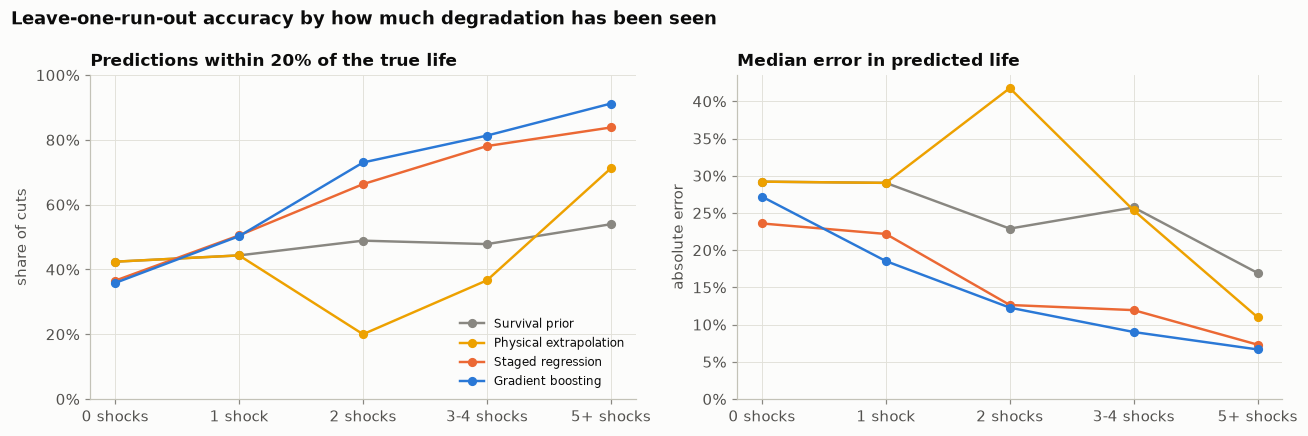

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"prior": ps.MUTED, "extrapolation": ps.YELLOW, "staged": ps.ORANGE, "gbm": ps.BLUE}
x = np.arange(len(STAGES))
for ax, tab, title, ylab in ((axes[0], tab_w20, "Predictions within 20% of the true life", "share of cuts"),
                             (axes[1], tab_ape, "Median error in predicted life", "absolute error")):
    for m in MODELS:
        ax.plot(x, tab[LABELS[m]].values, marker="o", ms=5, color=colors[m], label=LABELS[m])
    ax.set_xticks(x); ax.set_xticklabels(STAGES); ax.set_title(title); ax.set_ylabel(ylab); ax.set_ylim(0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend(fontsize=8, loc="lower right"); axes[0].set_ylim(0, 1)
fig.suptitle("Leave-one-run-out accuracy by how much degradation has been seen", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "08_model_comparison.png"); plt.show()

**Findings**

- **Before the first shock, no model beats the survival prior.** The prior puts 42% of predictions within 20% of the true life; the regression and the boosted model manage 36 to 37%. On the plateau there is nothing in the degradation features to learn from, so the simplest method is kept for that stage.
- **One shock is not enough either.** All learned models reach about 50%, against 44% for the prior. A single shock says degradation has started but not how fast it will go.
- **From the second shock on, learning pays off quickly.** The boosted model reaches 73% within 20% after two shocks, 81% after three or four and 91% after five or more, with a median error falling from 12% to 7%. The prior stays near 50% throughout.
- **The naive physical extrapolation is worse than knowing nothing until five or more shocks.** At two shocks only 20% of its predictions are within 20%. The reason is the transition found in notebook 1: the first intervals are about twice as long as the steady ones, so extrapolating them overestimates life. The learned models use the same physics and correct for that bias.
- **Boosting beats the staged regression by a consistent but modest margin.** The staged regression is kept as the readable reference; it gets most of the gain with a handful of coefficients.

**Final model:** survival prior while no shock has been seen, gradient boosting afterwards. Weighted by the stage mix of the test set, its local challenge score is 0.63, against 0.51 for the prior alone and 0.48 for the physical extrapolation. The choice of model per stage was made on these same leave-one-run-out results, so the 0.63 is slightly optimistic.

## 2.4 Watching a prediction evolve

The tables average over many cuts. The plot below follows four held-out runs instead: at each cut-off cycle, what life did the final model predict, having never seen that run?

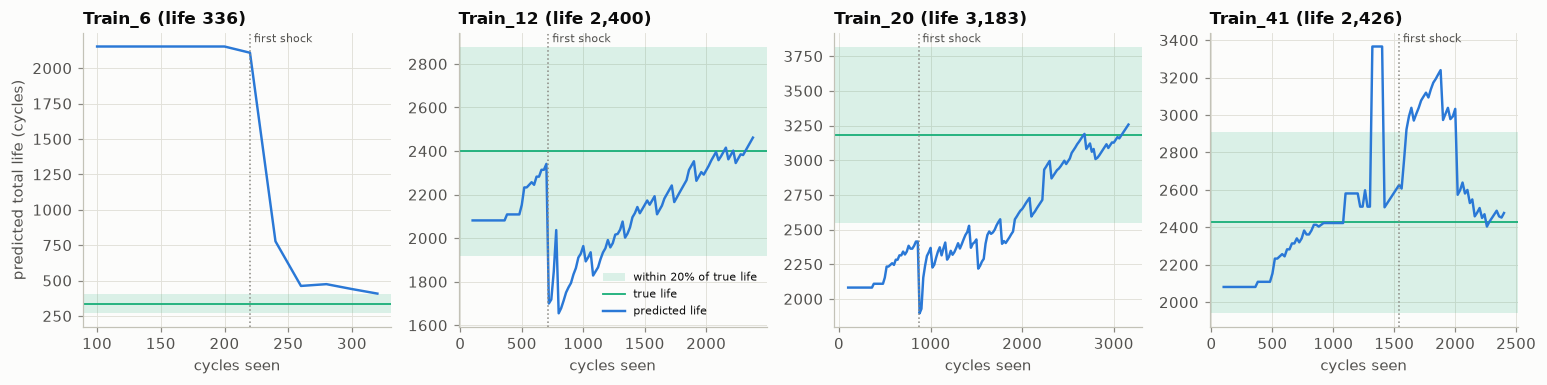

In [6]:
show = [6, 12, 20, 41]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, r in zip(axes, show):
    d = E[E.run == r]
    life = d.life.iloc[0]
    ax.axhspan(0.8 * life, 1.2 * life, color=ps.AQUA, alpha=0.15, linewidth=0, label="within 20% of true life")
    ax.axhline(life, color=ps.AQUA, lw=1.2, label="true life")
    ax.plot(d.t, d.final, color=ps.BLUE, label="predicted life")
    ax.axvline(first_shocks[r], color=ps.MUTED, lw=1, ls=":")
    ax.text(first_shocks[r], ax.get_ylim()[1], " first shock", fontsize=7, color=ps.INK2, va="top")
    ax.set_title(f"Train_{r} (life {life:,})"); ax.set_xlabel("cycles seen")
axes[0].set_ylabel("predicted total life (cycles)"); axes[1].legend(fontsize=7, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "09_prediction_evolution.png"); plt.show()

**Reading the plot**

- `Train_6` is the shortest run in the data (336 cycles). The model predicts a typical life of about 2,100 until the first shock at cycle 220, then corrects within 40 cycles. For most of the run it was badly wrong, and nothing in the data could have told it otherwise.
- `Train_12` and `Train_20` show the usual pattern after the first shock: the prediction drops, then climbs as the intervals between shocks reveal a slow pace. `Train_20` is a long run (3,183 cycles) and is underestimated until about cycle 2,200.
- `Train_41` has a late first shock (cycle 1,539). The plateau prediction rises as the run outlives more and more of the training runs, and becomes jumpy past cycle 1,300, where only a handful of training runs are still on the plateau to compare with.

This is also how the model would be used in service: re-run after every cycle, with the estimate tightening as shocks accumulate.

## 2.5 Where the errors are

Before the first shock the model is choosing a typical life. That is right for typical runs and badly wrong for unusual ones.

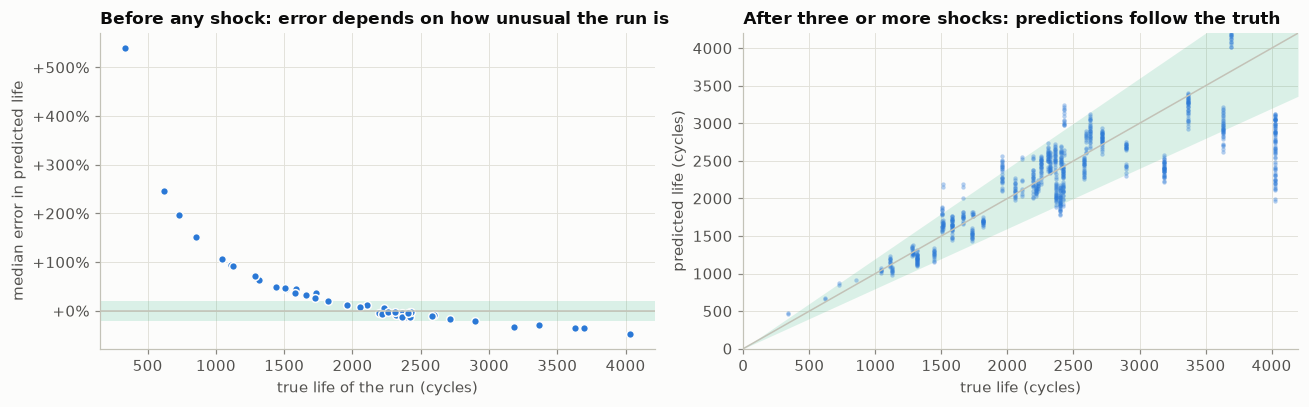

runs whose plateau-phase prediction is off by more than 50%: {6: {'life': 336, 'rel': 5.41}, 7: {'life': 621, 'rel': 2.47}, 8: {'life': 855, 'rel': 1.52}, 16: {'life': 1316, 'rel': 0.64}, 21: {'life': 1318, 'rel': 0.63}, 22: {'life': 1112, 'rel': 0.94}, 23: {'life': 1123, 'rel': 0.92}, 24: {'life': 726, 'rel': 1.97}, 28: {'life': 1045, 'rel': 1.06}, 38: {'life': 1276, 'rel': 0.72}, 47: {'life': 1283, 'rel': 0.71}}


In [7]:
d0 = E[(E.n_shocks == 0) & E.test_like]
per_run = d0.assign(rel=(d0.final - d0.life) / d0.life).groupby("run").agg(life=("life", "first"), rel=("rel", "median"))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.axhspan(-0.2, 0.2, color=ps.AQUA, alpha=0.15, linewidth=0)
ax.scatter(per_run.life, per_run.rel, s=26, color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=1)
ax.axhline(0, color=ps.AXIS, lw=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_title("Before any shock: error depends on how unusual the run is"); ax.set_xlabel("true life of the run (cycles)"); ax.set_ylabel("median error in predicted life")

ax = axes[1]
late = E[(E.n_shocks >= 3) & E.test_like]
ax.plot([0, 4200], [0, 4200], color=ps.AXIS, lw=1)
ax.fill_between([0, 4200], [0, 0.8 * 4200], [0, 1.2 * 4200], color=ps.AQUA, alpha=0.15, linewidth=0)
ax.scatter(late.life, late.final, s=8, color=ps.BLUE, alpha=0.35, linewidth=0)
ax.set_xlim(0, 4200); ax.set_ylim(0, 4200)
ax.set_title("After three or more shocks: predictions follow the truth"); ax.set_xlabel("true life (cycles)"); ax.set_ylabel("predicted life (cycles)")
fig.tight_layout(); fig.savefig(FIG / "10_error_anatomy.png"); plt.show()
print("runs whose plateau-phase prediction is off by more than 50%:", per_run[per_run.rel.abs() > 0.5].round(2).to_dict("index"))

**Findings**

- Every run whose plateau-phase prediction is off by more than 50% is a **short-lived** run (life under 1,320 cycles), and every one is overestimated. There are 11 of them among 46. A typical-life guess is the best available on the plateau, and it fails exactly for the doors that matter most in maintenance: the ones that fail early.
- After three or more shocks the predictions follow the truth, with most points inside the 20% band. The exception is the very longest runs (above 3,500 cycles), where predictions scatter well outside the band: there are only three of them to learn from.

## 2.6 A finding about the dataset: the sensors identify the recording session

Notebook 1 found one plateau-phase sensor feature slightly above the noise ceiling and promised to re-test it under cross-validation. Here is that test: the boosting model is given seven extra features, each the average of a sensor summary over cycles 20 to 100, long before any degradation.

within 20%                                  median error                            
           Gradient boosting Boosting + session features Gradient boosting Boosting + session features
0 shocks               0.358                       0.440             0.272                       0.204
1 shock                0.503                       0.560             0.185                       0.177
2 shocks               0.730                       0.741             0.123                       0.123
3-4 shocks             0.813                       0.791             0.090                       0.092
5+ shocks              0.912                       0.895             0.067                       0.063

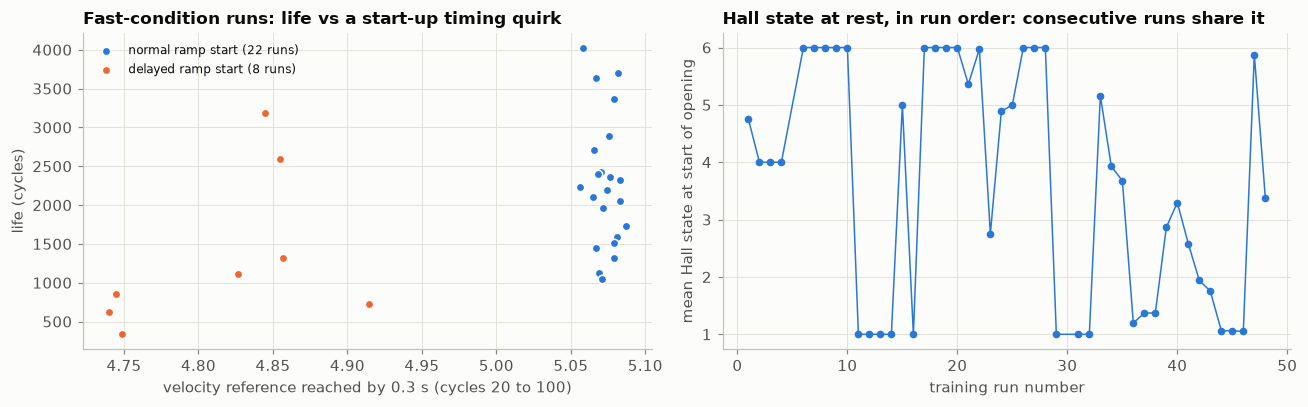

                    count     min     50%     max
ramp                                             
delayed ramp start    8.0   336.0   983.5  3183.0
normal ramp start    22.0  1045.0  2215.0  4029.0


In [8]:
cmp_cols = ["gbm", "gbm_session"]
tab_s = pd.concat({"within 20%": by_stage(TL, cmp_cols, within20), "median error": by_stage(TL, cmp_cols, med_ape)}, axis=1)
display(tab_s.round(3))

run_tab = pd.DataFrame({"life": lives, "first_shock": first_shocks}).join(sig_tr[["Cl_vel_ref_max", "Op_hall_first", "Cl_drv_temp_mean"]])
fast = run_tab[~slow_tr.reindex(run_tab.index)]
fast = fast.assign(ramp=np.where(fast.Cl_vel_ref_max < 5.0, "delayed ramp start", "normal ramp start"))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
for grp, col in (("normal ramp start", ps.BLUE), ("delayed ramp start", ps.ORANGE)):
    g = fast[fast.ramp == grp]
    ax.scatter(g.Cl_vel_ref_max, g.life, s=30, color=col, edgecolor=ps.SURFACE, linewidth=1, label=f"{grp} ({len(g)} runs)")
ax.set_title("Fast-condition runs: life vs a start-up timing quirk"); ax.set_xlabel("velocity reference reached by 0.3 s (cycles 20 to 100)"); ax.set_ylabel("life (cycles)"); ax.legend(fontsize=8)
ax = axes[1]
ax.plot(run_tab.index, run_tab.Op_hall_first, marker="o", ms=4, lw=1, color=ps.BLUE)
ax.set_title("Hall state at rest, in run order: consecutive runs share it"); ax.set_xlabel("training run number"); ax.set_ylabel("mean Hall state at start of opening")
fig.tight_layout(); fig.savefig(FIG / "11_session_signature.png"); plt.show()
print(fast.groupby("ramp").life.describe()[["count", "min", "50%", "max"]])

**Findings**

- **The extra features help, but only early.** On the plateau the share within 20% rises from 36% to 44% and the median error falls from 27% to 20%. After one shock it rises from 50% to 56%. From two shocks on there is no gain.
- **They help because they identify the recording session, not the door's condition.**
  - Left plot: eight fast-condition runs start their velocity ramp slightly late. Their median life is 984 cycles, against 2,215 for the other 22. A start-up timing quirk has no way of shortening a door's life; those runs were simply recorded together, with a faster shock schedule.
  - Right plot: the Hall state in which the motor rests is shared by blocks of consecutive runs, which again marks runs recorded in the same session.
- Since the shocks are injected by a script, a session is really a group of runs that share injection settings. Features that identify the session therefore predict life **in this dataset**. They would say nothing about a door in service.

**Decision.** This is a batch effect, the same kind of information as the file timestamps set aside in notebook 1. The main model does not use it. A second submission that does use it for runs with at most one shock is written alongside, so the difference can be measured on the leaderboard: in leave-one-run-out its weighted score is 0.64 against 0.63, a small gain concentrated in the earliest stage.

In [9]:
tab_final = pd.concat({"within 20%": by_stage(TL, ["final", "final_session"], within20)}, axis=1)
sc2 = score_table(TL, ["final", "final_session"])
sc2.loc["weighted by test stage mix"] = (sc2.mul(test_stage_mix / test_stage_mix.sum(), axis=0)).sum()
display(tab_final.round(2)); display(sc2.round(3))

within 20%                         
           Final model Final + session features
0 shocks          0.42                     0.44
1 shock           0.50                     0.56
2 shocks          0.73                     0.73
3-4 shocks        0.81                     0.81
5+ shocks         0.91                     0.91

,Final model,Final + session features
0 shocks,0.485,0.494
1 shock,0.513,0.544
2 shocks,0.638,0.638
3-4 shocks,0.723,0.723
5+ shocks,0.746,0.746
weighted by test stage mix,0.629,0.637


## 2.7 How uncertain is a prediction?

The leave-one-run-out errors are out-of-sample, so their spread is an honest picture of how wrong the model can be at each stage. The table gives the range that contained 80% of true lives, as a multiple of the predicted life.

In [10]:
ratio = np.log(TL.life / TL.final)
bands = ratio.groupby(TL.stage).quantile([0.1, 0.5, 0.9]).unstack().reindex(STAGES)
bands = np.exp(bands).rename(columns={0.1: "low (10%)", 0.5: "median", 0.9: "high (90%)"})
bands["width (high / low)"] = bands["high (90%)"] / bands["low (10%)"]
bands.round(2)

,low (10%),median,high (90%),width (high / low)
stage,,,,
0 shocks,0.58,0.99,1.50,2.57
1 shock,0.81,1.07,1.56,1.92
2 shocks,0.82,1.00,1.39,1.70
3-4 shocks,0.86,1.00,1.29,1.50
5+ shocks,0.89,1.03,1.33,1.50


**Findings**

- On the plateau, 80% of true lives fall between 0.58 and 1.50 times the prediction. That is a range of 2.6 to 1.
- The range narrows with every stage, to 0.86 to 1.29 times the prediction after three or four shocks.
- At every stage in the region where test runs are cut, the 80% range is wider than the 20% band the challenge metric demands. A high score on every test run is therefore not something the degradation signal can deliver; a good model gets most of the later-stage runs inside the band and some of the early ones by luck.

These ranges are empirical, from 46 runs, and are applied per stage. They are a description of past errors, not a guarantee.

## 2.8 Predictions for the 19 test runs

The models are refitted on all 46 training runs and applied to each test run as it stands at its last recorded cycle.

In [11]:
rows = []
for r, d in test.groupby("run"):
    f = prefix_features(health_series(d), slow_te[r]); f.update(run=r, files=len(d))
    rows.append(f)
T = pd.DataFrame(rows).set_index("run").join(sig_te[M.SESSION_FEATURES])
T["stage"] = stage_of(T.n_shocks)
pred = M.predict_all(examples, T, lives, first_shocks)
T = T.join(pred[["prior", "gbm", "final", "final_session"]])
T["low"] = np.maximum(T.final * T.stage.map(bands["low (10%)"]), T.t + 1)
T["high"] = T.final * T.stage.map(bands["high (90%)"])
out = T[["stage", "t", "hi_now", "final", "low", "high", "final_session"]].rename(columns={
    "t": "cycles seen", "hi_now": "closing position", "final": "predicted life", "low": "80% low", "high": "80% high", "final_session": "with session features"})
out.round(0)

,stage,cycles seen,closing position,predicted life,80% low,80% high,with session features
run,,,,,,,
1,3-4 shocks,1796,161.0,2947.0,2532.0,3800.0,2947.0
2,1 shock,1179,181.0,2602.0,2108.0,4048.0,2535.0
3,0 shocks,253,190.0,2109.0,1232.0,3160.0,1680.0
4,1 shock,1350,188.0,2728.0,2210.0,4243.0,3115.0
5,5+ shocks,3229,113.0,4271.0,3794.0,5676.0,4271.0
6,5+ shocks,1132,113.0,1508.0,1340.0,2004.0,1508.0
7,0 shocks,567,190.0,2257.0,1318.0,3382.0,1926.0
8,3-4 shocks,927,155.0,1890.0,1624.0,2438.0,1890.0
9,0 shocks,889,189.0,2423.0,1415.0,3631.0,1588.0


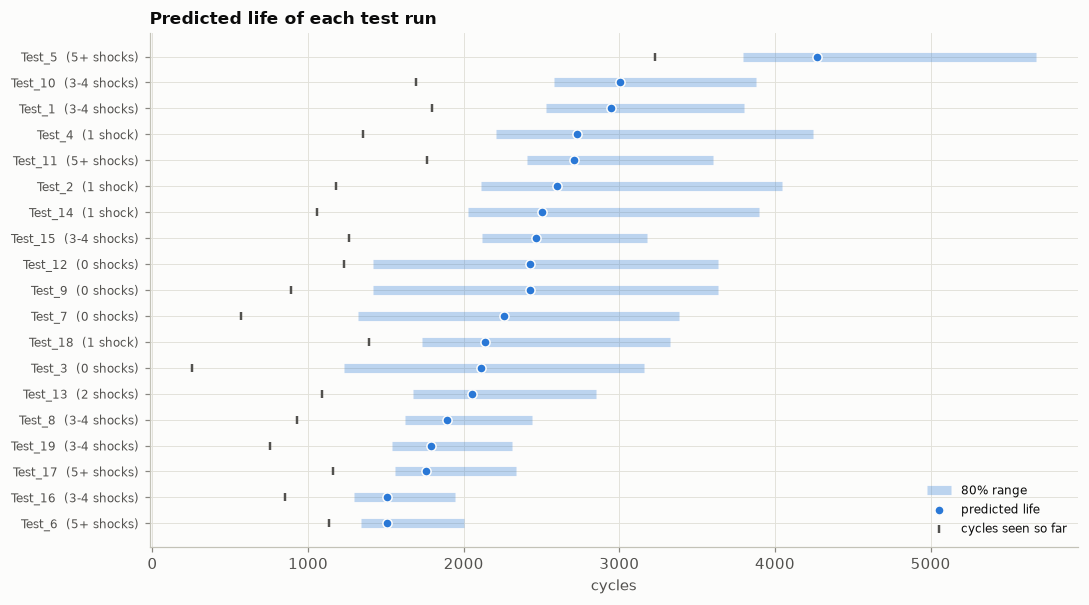

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.6))
order = T.sort_values("final").index
y = np.arange(len(order))
ax.hlines(y, T.loc[order, "low"], T.loc[order, "high"], color=ps.BLUE, alpha=0.3, lw=6, label="80% range")
ax.scatter(T.loc[order, "final"], y, s=36, color=ps.BLUE, zorder=3, edgecolor=ps.SURFACE, linewidth=1, label="predicted life")
ax.scatter(T.loc[order, "t"], y, s=30, color=ps.INK2, marker="|", zorder=3, label="cycles seen so far")
ax.set_yticks(y); ax.set_yticklabels([f"Test_{r}  ({T.stage[r]})" for r in order], fontsize=8)
ax.set_xlabel("cycles"); ax.set_title("Predicted life of each test run"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "12_test_predictions.png"); plt.show()

**Reading the predictions**

- Predicted lives range from about 1,500 to 4,300 cycles.
- The four runs with no shock yet (`Test_3`, `Test_7`, `Test_9`, `Test_12`) all receive a typical life of 2,100 to 2,400 cycles with the widest ranges. These are the predictions most likely to be wrong, and the session-feature variant disagrees most on exactly three of them (`Test_3`, `Test_7`, `Test_9` show the delayed ramp start and are predicted 1,600 to 1,900 instead).
- The tightest predictions are for runs with several shocks and a clear pace, such as `Test_6`, `Test_16` and `Test_17`.

## 2.9 Submission file

The submission needs one row per test measurement file: test id and RUL, semicolon-separated, no header. RUL follows the organisers' convention found in notebook 1: files are paired from the end of the run.

In [13]:
def write_submission(life_by_run, path):
    parts = []
    for r in sorted(test.run.unique()):
        n_files = int((test.run == r).sum())
        i = np.arange(n_files)
        rul = np.ceil((2 * life_by_run[r] - i) / 2).astype(int)
        parts.append(pd.DataFrame({"test": r, "rul": rul}))
    sub = pd.concat(parts, ignore_index=True)
    sub.to_csv(path, sep=";", header=False, index=False)
    return sub

sub = write_submission(T.final.round(), RES / "submission.csv")
sub_s = write_submission(T.final_session.round(), RES / "submission_session_features.csv")
T[["stage", "t", "hi_now", "n_shocks", "prior", "gbm", "final", "low", "high", "final_session"]].round(1).to_csv(RES / "test_predictions.csv")
E[["run", "t", "life", "stage", "test_like", "hi_now"] + list(loro.columns)].round(1).to_csv(RES / "loro_predictions.csv", index=False)

# checks against the rejection reasons on the leaderboard
files_per_test = test.groupby("run").size()
assert len(sub) == len(test) == 47187
assert (sub.groupby("test").size() == files_per_test).all(), "row count mismatch"
assert sub.test.nunique() == 19 and sub.rul.min() >= 1
assert (sub.groupby("test").rul.apply(lambda s: (s.diff().dropna() <= 0).all())).all(), "RUL must not increase"
print(f"submission.csv: {len(sub):,} rows, {sub.test.nunique()} tests, RUL from {sub.rul.min()} to {sub.rul.max()}")
print(sub.head(4).to_csv(sep=";", header=False, index=False))

submission.csv: 47,187 rows, 19 tests, RUL from 376 to 4271
1;2947
1;2947
1;2946
1;2946



## 2.10 Conclusions

**What was built**

- A training set of 4,436 cut-off examples from 46 runs, with features that describe only the degradation staircase.
- Two baselines and two models, compared by leave-one-run-out.
- A final model (survival prior before the first shock, gradient boosting after it), prediction ranges by stage, and a validated submission file.

**What was learned**

1. Remaining life becomes predictable from the **second shock**: about three in four predictions within 20%, rising to nine in ten after five shocks.
2. Before the first shock, a sophisticated model is no better than the median of comparable past runs, and both are right less than half the time.
3. Obvious physics applied naively (extrapolating the shock rate) is worse than a blind guess early on. The value of the model is in correcting a known bias, not in finding hidden signal.
4. Sensor features that appear to give early warning are identifying the recording session. Catching that before trusting it is the most transferable lesson of the project.

**Limitations**

- 46 independent runs is a small sample. Stage-level numbers, especially for the 1-shock and 2-shock stages, carry real uncertainty.
- The challenge score is computed with a local reading of an ambiguous formula. It ranks models; it does not predict the leaderboard value.
- The data is semi-synthetic: real hardware, but degradation injected by a script on a random schedule. The conclusion that the plateau carries no warning is a statement about this test bench. A real door wearing out might well show precursors in current or temperature.
- Model choice per stage used the same cross-validation that reports the scores.

**Next steps**

- Upload `results/submission.csv`, then `results/submission_session_features.csv`, and compare the leaderboard scores with the 0.63 and 0.64 expected here.
- If the session variant scores clearly higher, that confirms the batch effect extends to the test set and is worth reporting to the organisers.